# Notebook 05 - Evaluacion comparativa (Fase 5 CRISP-DM)

**Objetivo:** sobre el **test set** (que no se ha tocado hasta ahora), comparar
SVM vs Random Forest vs CNN. Producir todas las figuras para el informe IEEE:

1. Matriz de confusion 3x3 por modelo.
2. Matriz 6x6 (sesgo por especie) por modelo.
3. Accuracy condicional por fruta.
4. Tabla y figura comparativa de F1-macro.

> Requiere haber ejecutado los notebooks 03 y 04 (modelos guardados).


In [2]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))

from src.data.preprocess import load_and_preprocess_image, CLASS_NAMES
from src.utils.features import extract_features
from src.models.ml_models import SVMClassifier, RFClassifier
from src.evaluation.evaluate import (
    classification_report_dict, plot_confusion_matrix,
    plot_bias_matrix, accuracy_per_fruit, compare_models,
)

FIG_DIR = REPO_ROOT / "outputs" / "figures" / "eval"
CKPT_DIR = REPO_ROOT / "experiments" / "checkpoints"
FIG_DIR.mkdir(parents=True, exist_ok=True)
test_df = pd.read_csv(REPO_ROOT / "data" / "processed" / "test_manifest.csv")
y_test = test_df["quality"].values
fruit_test = test_df["fruit"].values
print(f"Test set: {len(test_df)} imgs")

Test set: 1171 imgs


## 1. Predicciones de SVM y RF (features 141-D)

In [3]:
# Cargar features cacheados
z = np.load(REPO_ROOT / "data" / "processed" / "features_test.npz", allow_pickle=True)
X_test = z["X"]; assert (z["y"] == y_test).all()

svm = SVMClassifier.load(CKPT_DIR / "svm_rbf.joblib")
rf = RFClassifier.load(CKPT_DIR / "random_forest.joblib")

y_pred_svm = svm.predict(X_test)
y_pred_rf = rf.predict(X_test)
print(f"SVM acc test: {(y_pred_svm == y_test).mean():.4f}")
print(f"RF  acc test: {(y_pred_rf  == y_test).mean():.4f}")

SVM acc test: 0.9846
RF  acc test: 0.9727


## 2. Predicciones de la CNN

In [4]:
import tensorflow as tf
from src.data.preprocess import get_val_augmentation

label2idx = {c: i for i, c in enumerate(CLASS_NAMES)}
idx2label = {i: c for c, i in label2idx.items()}

# Cargar modelo (best o final segun preferencia)
cnn = tf.keras.models.load_model(CKPT_DIR / "cnn_best.keras")

paths = (REPO_ROOT / test_df["path"]).astype(str).values
imgs = np.stack([load_and_preprocess_image(p) for p in paths])
y_proba_cnn = cnn.predict(imgs, batch_size=32, verbose=0)
y_pred_cnn = np.array([idx2label[i] for i in np.argmax(y_proba_cnn, axis=1)])
print(f"CNN acc test: {(y_pred_cnn == y_test).mean():.4f}")

CNN acc test: 0.9607


## 3. Matrices de confusion 3x3 (target)

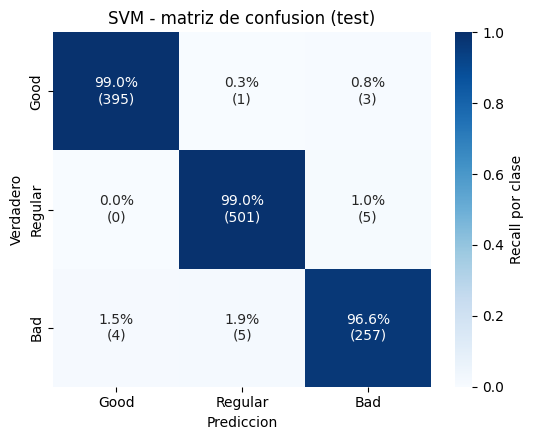

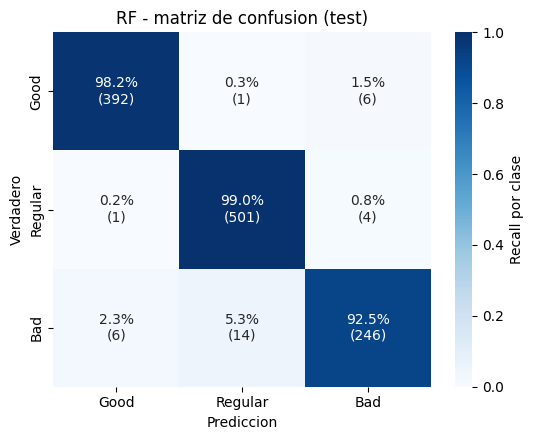

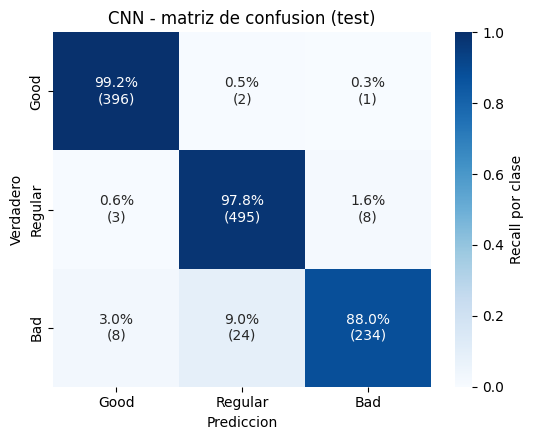

In [5]:
for name, y_pred, fname in [
    ("SVM", y_pred_svm, "01_cm_svm.svg"),
    ("RF",  y_pred_rf,  "02_cm_rf.svg"),
    ("CNN", y_pred_cnn, "03_cm_cnn.svg"),
]:
    plot_confusion_matrix(y_test, y_pred,
        title=f"{name} - matriz de confusion (test)",
        out_path=FIG_DIR / fname)
    plt.show()

## 4. Analisis de sesgo: matrices 6x6 por fruta

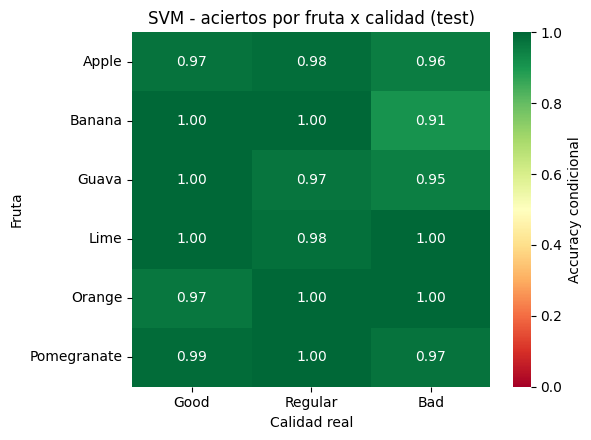


=== SVM: accuracy condicional por fruta ===
      fruit   n  accuracy  f1_macro
     Orange 125  0.992000  0.992385
Pomegranate 497  0.987928  0.989149
       Lime 160  0.987500  0.982966
     Banana 142  0.978873  0.977472
      Apple 128  0.976562  0.969376
      Guava 119  0.974790  0.968310


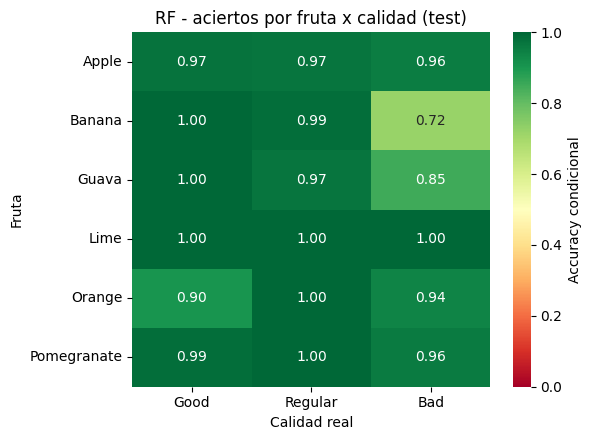


=== RF: accuracy condicional por fruta ===
      fruit   n  accuracy  f1_macro
       Lime 160  1.000000  1.000000
Pomegranate 497  0.981891  0.983704
      Apple 128  0.968750  0.962638
     Orange 125  0.968000  0.950206
      Guava 119  0.957983  0.945275
     Banana 142  0.929577  0.920635


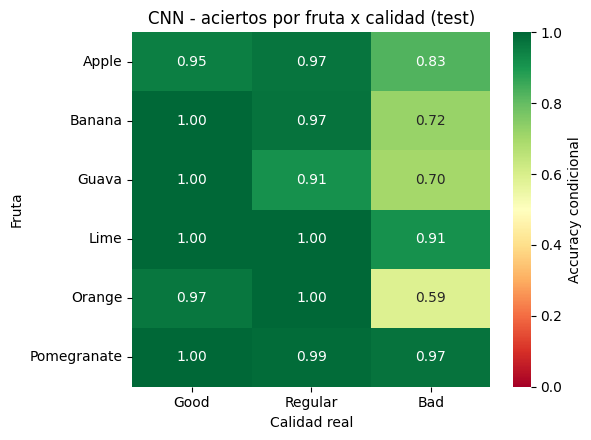


=== CNN: accuracy condicional por fruta ===
      fruit   n  accuracy  f1_macro
Pomegranate 497  0.989940  0.990098
       Lime 160  0.987500  0.981762
      Apple 128  0.937500  0.924127
     Orange 125  0.936000  0.885207
     Banana 142  0.922535  0.913716
      Guava 119  0.899160  0.871533


In [6]:
for name, y_pred, fname in [
    ("SVM", y_pred_svm, "04_bias_svm.svg"),
    ("RF",  y_pred_rf,  "05_bias_rf.svg"),
    ("CNN", y_pred_cnn, "06_bias_cnn.svg"),
]:
    plot_bias_matrix(y_test, y_pred, fruit_test,
        title=f"{name} - aciertos por fruta x calidad (test)",
        out_path=FIG_DIR / fname)
    plt.show()
    print(f"\n=== {name}: accuracy condicional por fruta ===")
    print(accuracy_per_fruit(y_test, y_pred, fruit_test).to_string(index=False))

## 5. Tabla comparativa F1-macro + figura

In [8]:
results = {
    "SVM (RBF)":     {"y_true": y_test, "y_pred": y_pred_svm},
    "Random Forest": {"y_true": y_test, "y_pred": y_pred_rf},
    "CNN":           {"y_true": y_test, "y_pred": y_pred_cnn},
}
table = compare_models(results, out_path=FIG_DIR / "07_comparativa_modelos.svg")
print(table.round(4).to_string(index=False))

# Guardar resumen final en MD para el informe IEEE
out = REPO_ROOT / "outputs" / "resultados_finales.md"
lines = ["# Resultados finales - test set\n\n"]
lines.append(table.round(4).to_markdown(index=False) + "\n\n")
out.write_text("".join(lines), encoding="utf-8")
print(f"\n[OK] Resumen guardado en {out}")

        model  accuracy  f1_macro  f1_Good  f1_Regular  f1_Bad
    SVM (RBF)    0.9846    0.9824   0.9900      0.9891  0.9680
Random Forest    0.9727    0.9685   0.9825      0.9804  0.9425
          CNN    0.9607    0.9554   0.9826      0.9640  0.9194

[OK] Resumen guardado en C:\Users\Kevin Cifuentes\Desktop\Estudios\APO3\Proyecto\APO3_TrabajoFinal\APO3_TrabajoFinal\Apo3_ProyectoFinal\outputs\resultados_finales.md


## 6. Conclusiones para el informe IEEE

A partir de la tabla y las matrices de sesgo, responder en la seccion 'Analisis de resultados' del informe:

1. **Cual modelo gana en F1-macro y por que?** (CNN suele ganar si tiene datos suficientes; SVM/RF son competitivos en problemas con features bien disenados.)
2. **El mejor modelo es uniformemente bueno entre frutas?** (Si la matriz 6x6 es verde uniforme, no hay sesgo por especie. Si hay filas rojas, el modelo no generaliza para esa fruta.)
3. **Que clase es la mas dificil?** (Bad suele ser la mas dificil porque tiene menos ejemplos y mayor variabilidad visual.)
4. **El modelo aprende calidad o atajos?** (Si CNN tiene accuracy condicional muy variable por especie, sugiere que aprende fruta antes que calidad.)
